In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd

df = pd.read_csv('/content/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [3]:
import pandas as pd

df = pd.read_csv('/content/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.columns = df.columns.str.strip()

df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [5]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [7]:
df['total_assets'] = (
      df['residential_assets_value']
          + df['commercial_assets_value']
              + df['luxury_assets_value']
                  + df['bank_asset_value']
                  )


In [8]:
df['loan_income_ratio'] = (
      df['loan_amount'] /
          df['income_annum']
          )


In [9]:
total_applications = len(df)

approved = len(df[df['loan_status']==" Approved"])

rejected = len(df[df['loan_status']==" Rejected"])

approval_rate = approved/total_applications*100

print(total_applications)
print(approved)
print(rejected)
print(approval_rate)

4269
2656
1613
62.215975638322796


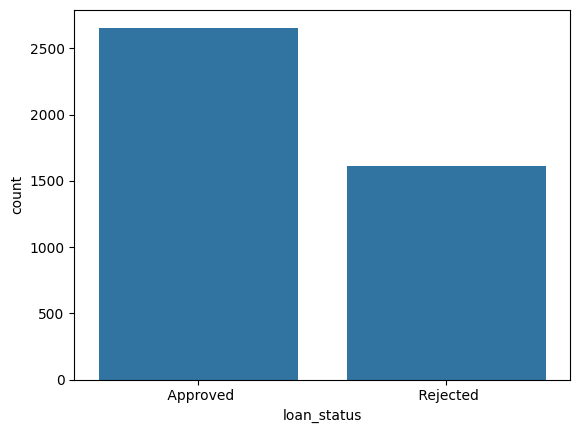

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='loan_status',
        data=df
        )

plt.show()

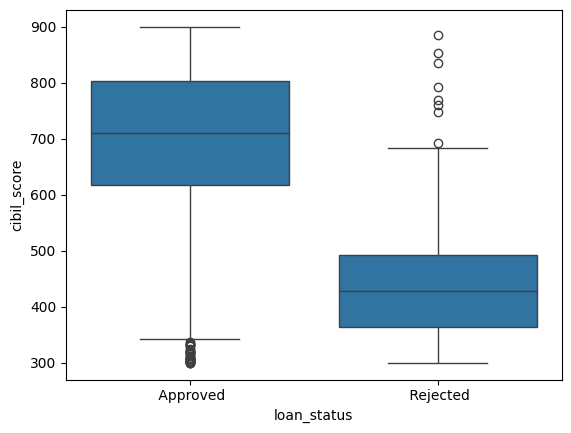

In [12]:
sns.boxplot(
      x='loan_status',
          y='cibil_score',
              data=df
              )

plt.show()


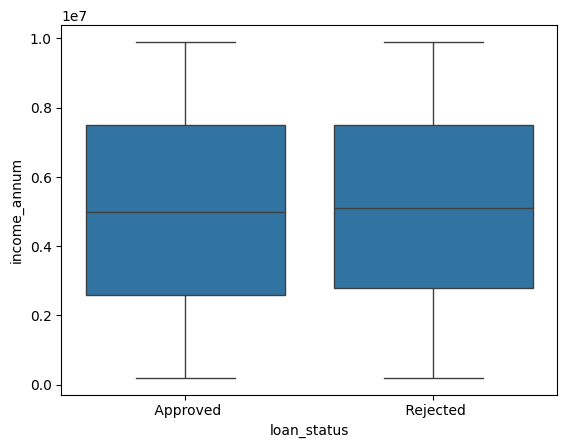

In [14]:
sns.boxplot(
      x='loan_status',
          y='income_annum',
              data=df
              )

plt.show()


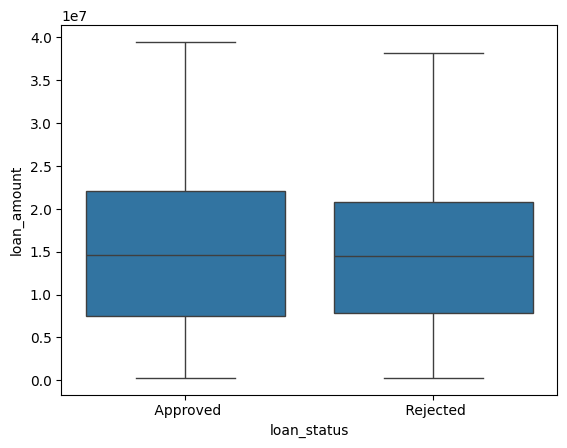

In [15]:
sns.boxplot(
      x='loan_status',
          y='loan_amount',
              data=df
              )

plt.show()


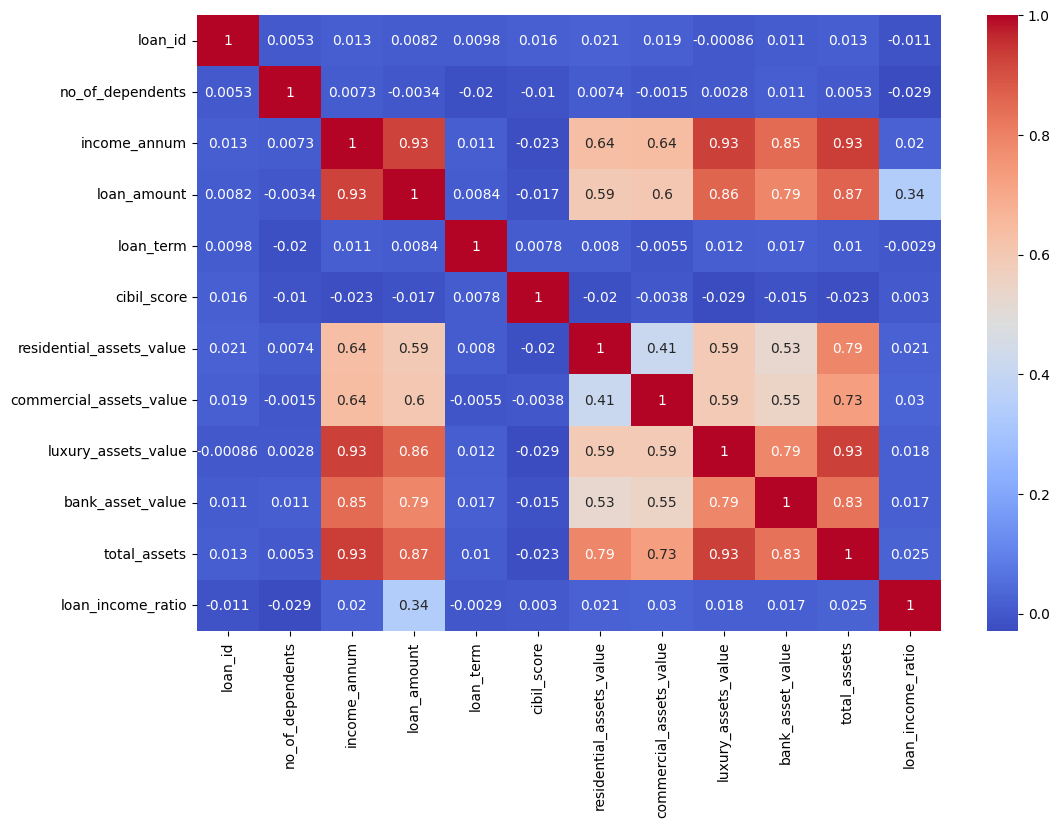

In [16]:
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
        annot=True,
            cmap='coolwarm'
            )

plt.show()

In [17]:
def risk(score):

      if score >= 750:
              return "Low Risk"

      elif score >= 650:
          return "Medium Risk"

      else:
         return "High Risk"

df['risk_level'] = df['cibil_score'].apply(risk)

In [18]:
df['risk_level'].value_counts()

,count
risk_level,
High Risk,2468
Low Risk,1056
Medium Risk,745


In [19]:
df.to_csv(
      'loan_risk_cleaned.csv',
          index=False
          )


In [20]:
from google.colab import files
files.download('loan_risk_cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>